# 05 - Option 5: Ring/distance ICH prior + Option 1 warm-start

Option 4 thua Option 1 vì raw ICH prior quá sparse và không cùng nhãn với PHE: ICH là hematoma, còn PHE là vùng phù quanh hematoma. Option 5 sửa đúng điểm đó:

1. Reuse **raw ICH teacher priors** đã sinh ở Option 4.
2. Chuyển raw prior thành:
   - `raw_prior`: xác suất hematoma thô.
   - `ring_prior`: vùng vòng quanh hematoma, phù hợp hơn với PHE.
   - `distance_prior`: tín hiệu giảm dần theo khoảng cách tới hematoma.
3. Train PHE student với 4 input channels:
   - CT brain window `[-20, 100] HU`
   - raw ICH prior
   - ring prior
   - distance prior
4. Warm-start student từ checkpoint **Option 1 PHE-only U-Net**. Kênh CT nhận weight cũ; các kênh prior khởi tạo bằng 0 để ban đầu model hành xử như Option 1.
5. Dùng **prior dropout** để model không bị ép phụ thuộc prior sai.

Mục tiêu: cải thiện hoặc ít nhất không tệ hơn Option 1, đồng thời kiểm tra xem prior đã xử lý đúng hơn có giúp không.


## Khác biệt với Option 4

| Thành phần | Option 4 | Option 5 |
|---|---|---|
| Prior đưa vào student | raw ICH prior | raw + ring + distance prior |
| Student init | train từ đầu | warm-start từ Option 1 |
| Bảo vệ khỏi negative transfer | không có | prior dropout + prior channels zero-init |
| Kỳ vọng | dễ bị kéo lệch về hematoma | giữ baseline PHE, học thêm context quanh hematoma |


In [1]:
INSTALL_BASIC_DEPS = False

if INSTALL_BASIC_DEPS:
    import sys
    import subprocess
    pkgs = ["numpy", "pandas", "matplotlib", "scipy", "nibabel", "tqdm"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])


In [2]:
from pathlib import Path
from dataclasses import dataclass, asdict


@dataclass
class Option5Config:
    project_root: Path = Path.cwd()
    seed: int = 42

    run_ring_prior_generation: bool = True
    run_student_training: bool = True
    run_final_eval: bool = True

    # Debug mode.
    debug_small_run: bool = False
    debug_train_cases: int = 8
    debug_val_cases: int = 4
    debug_test_cases: int = 4
    debug_epochs: int = 2

    # PHE student.
    image_size: int = 512
    epochs: int = 80
    batch_size: int = 4
    lr: float = 1e-5
    base_channels: int = 32
    weight_decay: float = 1e-4
    patience: int = 18
    min_delta: float = 1e-4
    amp: bool = True
    num_workers: int = 0

    # CT and prior settings.
    phe_window_low: float = -20.0
    phe_window_high: float = 100.0
    prior_dropout: float = 0.30
    positive_slice_weight: float = 4.0
    bce_pos_weight_clip: float = 50.0

    # Ring prior settings in physical mm.
    seed_min_threshold: float = 0.05
    seed_percentile: float = 99.2
    seed_min_voxels: int = 20
    ring_center_mm: float = 8.0
    ring_sigma_mm: float = 5.0
    ring_max_mm: float = 25.0
    distance_decay_mm: float = 12.0
    seed_dilation_iter: int = 1

    # Evaluation.
    threshold: float = 0.5
    tune_threshold_on_val: bool = True
    threshold_grid: tuple = (0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70)
    nsd_tolerance_mm: float = 1.0
    save_probability_npz: bool = False


CFG = Option5Config()
PROJECT_ROOT = CFG.project_root.resolve()

PHE_ROOT = PROJECT_ROOT / "PHE-SICH-CT-IDS" / "SubdatasetA_NIFIT" / "NIFIT"
PHE_IMAGE_DIR = PHE_ROOT / "set"
PHE_MASK_DIR = PHE_ROOT / "label"

OPTION1_SPLIT_PATH = PROJECT_ROOT / "outputs_option1_phe_sich_2d_unet" / "manifests" / "phe_sich_option1_patient_442_split.csv"
OPTION1_CKPT_PATH = PROJECT_ROOT / "outputs_option1_phe_sich_2d_unet" / "checkpoints" / "option1_unet2d_best.pt"
OPTION4_RAW_PRIOR_DIR = PROJECT_ROOT / "outputs_option4_ich_prior_transfer" / "teacher_priors_phe"

OUTPUT_ROOT = PROJECT_ROOT / "outputs_option5_ring_prior_warmstart"
MANIFEST_DIR = OUTPUT_ROOT / "manifests"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
RING_PRIOR_DIR = OUTPUT_ROOT / "ring_priors_phe"
PRED_DIR = OUTPUT_ROOT / "predictions"
LOG_DIR = OUTPUT_ROOT / "logs"

for p in [OUTPUT_ROOT, MANIFEST_DIR, TABLE_DIR, FIG_DIR, CHECKPOINT_DIR, RING_PRIOR_DIR, PRED_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root       :", PROJECT_ROOT)
print("Output root        :", OUTPUT_ROOT)
print("Option1 checkpoint :", OPTION1_CKPT_PATH)
print("Option4 raw priors :", OPTION4_RAW_PRIOR_DIR)


Project root       : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao
Output root        : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option5_ring_prior_warmstart
Option1 checkpoint : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option1_phe_sich_2d_unet\checkpoints\option1_unet2d_best.pt
Option4 raw priors : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\teacher_priors_phe


In [3]:
import os
import json
import math
import random
import time
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    import nibabel as nib
    NIB_AVAILABLE = True
except Exception as exc:
    nib = None
    NIB_AVAILABLE = False
    print("nibabel unavailable:", exc)

try:
    from scipy import ndimage
    SCIPY_AVAILABLE = True
except Exception as exc:
    ndimage = None
    SCIPY_AVAILABLE = False
    print("scipy unavailable:", exc)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
    TORCH_AVAILABLE = True
except Exception as exc:
    torch = nn = F = Dataset = DataLoader = WeightedRandomSampler = None
    TORCH_AVAILABLE = False
    print("torch unavailable; training/eval cells will skip:", exc)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


set_seed(CFG.seed)
DEVICE = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print({"nibabel": NIB_AVAILABLE, "scipy": SCIPY_AVAILABLE, "torch": TORCH_AVAILABLE, "device": DEVICE})


{'nibabel': True, 'scipy': True, 'torch': True, 'device': 'cuda'}


## 1. Shared helpers


In [4]:
def is_nifti(path: Path) -> bool:
    return path.name.endswith(".nii") or path.name.endswith(".nii.gz")


def strip_nii_suffix(path_or_name) -> str:
    name = Path(path_or_name).name
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return Path(name).stem


def load_nifti(path: Path, canonical: bool = True):
    if not NIB_AVAILABLE:
        raise ImportError("Install nibabel first.")
    img = nib.load(str(path))
    if canonical:
        img = nib.as_closest_canonical(img)
    data = np.asanyarray(img.dataobj)
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return data, spacing, img.affine


def header_info(path: Path) -> Dict:
    img = nib.load(str(path))
    shape = tuple(int(v) for v in img.shape[:3])
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return {"shape": shape, "spacing_x": spacing[0], "spacing_y": spacing[1], "spacing_z": spacing[2], "n_slices": shape[2]}


def mask_volume_stats(mask_path: Path, spacing: Tuple[float, float, float]) -> Dict:
    mask = np.asanyarray(nib.load(str(mask_path)).dataobj) > 0
    per_slice = mask.reshape((-1, mask.shape[2])).sum(axis=0)
    voxel_ml = float(np.prod(spacing) / 1000.0)
    return {"mask_voxels": int(mask.sum()), "mask_volume_ml": float(mask.sum() * voxel_ml), "positive_slices": int((per_slice > 0).sum())}


def window_ct(image: np.ndarray, low: float, high: float) -> np.ndarray:
    image = image.astype(np.float32, copy=False)
    image = np.clip(image, low, high)
    return ((image - low) / max(high - low, 1e-6)).astype(np.float32)


def resize_2d(array: np.ndarray, out_size: int, order: int = 1) -> np.ndarray:
    if array.shape[-2:] == (out_size, out_size):
        return array
    if not SCIPY_AVAILABLE:
        raise ImportError("Install scipy for resizing.")
    zoom_y = out_size / array.shape[-2]
    zoom_x = out_size / array.shape[-1]
    return ndimage.zoom(array, (zoom_y, zoom_x), order=order)


def preprocess_ct_slice(volume: np.ndarray, z: int, image_size: int = CFG.image_size) -> np.ndarray:
    x = window_ct(np.asarray(volume[:, :, z]), CFG.phe_window_low, CFG.phe_window_high)
    return resize_2d(x, image_size, order=1).astype(np.float32)


def preprocess_mask_slice(mask_volume: np.ndarray, z: int, image_size: int = CFG.image_size) -> np.ndarray:
    y = (np.asarray(mask_volume[:, :, z]) > 0).astype(np.float32)
    return (resize_2d(y, image_size, order=0) > 0.5).astype(np.float32)


def largest_mask_slice(mask_volume: np.ndarray) -> int:
    per_slice = (mask_volume > 0).reshape((-1, mask_volume.shape[2])).sum(axis=0)
    return int(np.argmax(per_slice))


def torch_load_checkpoint(path: Path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


## 2. Load PHE split and audit raw priors


In [5]:
def build_phe_manifest() -> pd.DataFrame:
    images = {strip_nii_suffix(p): p for p in PHE_IMAGE_DIR.iterdir() if p.is_file() and is_nifti(p)}
    masks = {strip_nii_suffix(p): p for p in PHE_MASK_DIR.iterdir() if p.is_file() and is_nifti(p)}
    rows = []
    for scan_id, img_path in sorted(images.items()):
        mask_path = masks.get(scan_id)
        if mask_path is None:
            continue
        info = header_info(img_path)
        spacing = (info["spacing_x"], info["spacing_y"], info["spacing_z"])
        stats = mask_volume_stats(mask_path, spacing)
        rows.append({"dataset": "PHE-SICH-CT-IDS", "patient_id": f"phe_{scan_id}", "scan_id": scan_id, "img_path": str(img_path), "mask_path": str(mask_path), **info, **stats})
    return pd.DataFrame(rows)


def make_patient_442_split(df: pd.DataFrame, seed: int = CFG.seed) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    rng = np.random.default_rng(seed)
    strata = pd.qcut(df["mask_volume_ml"].rank(method="first"), q=4, labels=False)
    split = np.array([""] * len(df), dtype=object)
    for _, part in df.groupby(strata):
        idx = part.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(n * 0.4))
        n_val = int(round(n * 0.4))
        split[idx[:n_train]] = "train"
        split[idx[n_train:n_train + n_val]] = "val"
        split[idx[n_train + n_val:]] = "test"
    df["split"] = split
    return df


if OPTION1_SPLIT_PATH.exists():
    phe_df = pd.read_csv(OPTION1_SPLIT_PATH)
    print("Loaded Option 1 split:", OPTION1_SPLIT_PATH)
else:
    phe_df = make_patient_442_split(build_phe_manifest())
    print("Built new split with seed:", CFG.seed)

if CFG.debug_small_run:
    phe_df = pd.concat([
        phe_df[phe_df["split"] == "train"].head(CFG.debug_train_cases),
        phe_df[phe_df["split"] == "val"].head(CFG.debug_val_cases),
        phe_df[phe_df["split"] == "test"].head(CFG.debug_test_cases),
    ], ignore_index=True)

phe_split_path = MANIFEST_DIR / "option5_phe_split.csv"
phe_df.to_csv(phe_split_path, index=False, encoding="utf-8")
train_rows = phe_df[phe_df["split"] == "train"].reset_index(drop=True)
val_rows = phe_df[phe_df["split"] == "val"].reset_index(drop=True)
test_rows = phe_df[phe_df["split"] == "test"].reset_index(drop=True)
display(phe_df.groupby("split").agg(cases=("scan_id", "count"), slices=("n_slices", "sum"), positive_slices=("positive_slices", "sum"), median_phe_ml=("mask_volume_ml", "median")).reset_index())

raw_prior_count = len(list(OPTION4_RAW_PRIOR_DIR.glob("*_ich_prior.npz"))) if OPTION4_RAW_PRIOR_DIR.exists() else 0
print("Raw Option 4 priors:", raw_prior_count, "at", OPTION4_RAW_PRIOR_DIR)


Loaded Option 1 split: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option1_phe_sich_2d_unet\manifests\phe_sich_option1_patient_442_split.csv


,split,cases,slices,positive_slices,median_phe_ml
0,test,24,799,130,2.548099
1,train,48,1368,284,2.585669
2,val,48,1434,269,2.512041


Raw Option 4 priors: 120 at D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option4_ich_prior_transfer\teacher_priors_phe


In [6]:
prior_audit_rows = []
for _, row in phe_df.iterrows():
    p = OPTION4_RAW_PRIOR_DIR / f"{row['scan_id']}_ich_prior.npz"
    if not p.exists():
        continue
    raw = np.load(p)["prior"].astype(np.float32)
    prior_audit_rows.append({
        "split": row["split"],
        "scan_id": row["scan_id"],
        "mean": float(raw.mean()),
        "p95": float(np.percentile(raw, 95)),
        "p99": float(np.percentile(raw, 99)),
        "max": float(raw.max()),
        "frac_gt_01": float((raw > 0.1).mean()),
        "frac_gt_03": float((raw > 0.3).mean()),
        "frac_gt_05": float((raw > 0.5).mean()),
    })
prior_audit_df = pd.DataFrame(prior_audit_rows)
if len(prior_audit_df):
    display(prior_audit_df.groupby("split")[["mean", "p95", "p99", "max", "frac_gt_01", "frac_gt_03", "frac_gt_05"]].mean())
    prior_audit_df.to_csv(TABLE_DIR / "option5_raw_prior_audit.csv", index=False)
else:
    print("No raw priors found. Run Option 4 prior generation first.")


,mean,p95,p99,max,frac_gt_01,frac_gt_03,frac_gt_05
split,,,,,,,
test,0.005797,0.001211,0.139561,1.0,0.008723,0.006097,0.005014
train,0.007702,0.001646,0.223695,1.0,0.011042,0.008151,0.006912
val,0.006860,0.001665,0.177659,1.0,0.010038,0.007217,0.006048


## 3. Build ring/distance priors from raw ICH prior


In [7]:
def adaptive_seed_from_raw_prior(raw: np.ndarray) -> Tuple[np.ndarray, float]:
    raw = np.nan_to_num(raw.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0)
    positives = raw[raw > 0]
    if len(positives) == 0 or raw.max() <= 0:
        return np.zeros(raw.shape, dtype=bool), 1.0
    thr = max(CFG.seed_min_threshold, float(np.percentile(raw, CFG.seed_percentile)))
    if (raw >= thr).sum() < CFG.seed_min_voxels:
        thr = max(float(raw.max() * 0.50), 1e-6)
    seed = raw >= thr
    if seed.sum() > 0 and CFG.seed_dilation_iter > 0:
        seed = ndimage.binary_dilation(seed, iterations=CFG.seed_dilation_iter)
    return seed.astype(bool), float(thr)


def make_ring_distance_priors(raw: np.ndarray, spacing: Tuple[float, float, float]) -> Dict[str, np.ndarray]:
    raw = np.clip(np.nan_to_num(raw.astype(np.float32), nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0)
    seed, thr = adaptive_seed_from_raw_prior(raw)
    if seed.sum() == 0:
        zero = np.zeros_like(raw, dtype=np.float32)
        return {"raw": raw, "seed": zero, "ring": zero, "distance": zero, "threshold": thr, "seed_voxels": 0}

    dist_out = ndimage.distance_transform_edt(~seed, sampling=spacing).astype(np.float32)
    ring = np.exp(-0.5 * ((dist_out - CFG.ring_center_mm) / CFG.ring_sigma_mm) ** 2)
    ring = ring * (dist_out <= CFG.ring_max_mm) * (~seed)
    distance = np.exp(-dist_out / CFG.distance_decay_mm)
    distance[seed] = 1.0

    return {
        "raw": raw.astype(np.float32),
        "seed": seed.astype(np.float32),
        "ring": np.clip(ring, 0, 1).astype(np.float32),
        "distance": np.clip(distance, 0, 1).astype(np.float32),
        "threshold": thr,
        "seed_voxels": int(seed.sum()),
    }


ring_rows = []
if CFG.run_ring_prior_generation:
    for _, row in tqdm(phe_df.iterrows(), total=len(phe_df), desc="ring priors"):
        raw_path = OPTION4_RAW_PRIOR_DIR / f"{row['scan_id']}_ich_prior.npz"
        out_path = RING_PRIOR_DIR / f"{row['scan_id']}_ring_prior.npz"
        if not raw_path.exists():
            continue
        if out_path.exists():
            arr = np.load(out_path)
            ring_rows.append({"scan_id": row["scan_id"], "split": row["split"], "threshold": float(arr["threshold"]), "seed_voxels": int(arr["seed_voxels"]), "ring_mean": float(arr["ring"].mean()), "distance_mean": float(arr["distance"].mean())})
            continue
        raw = np.load(raw_path)["prior"].astype(np.float32)
        _, spacing, _ = load_nifti(Path(row["img_path"]))
        priors = make_ring_distance_priors(raw, spacing)
        np.savez_compressed(
            out_path,
            raw=priors["raw"].astype(np.float16),
            seed=priors["seed"].astype(np.uint8),
            ring=priors["ring"].astype(np.float16),
            distance=priors["distance"].astype(np.float16),
            threshold=np.array(priors["threshold"], dtype=np.float32),
            seed_voxels=np.array(priors["seed_voxels"], dtype=np.int32),
        )
        ring_rows.append({"scan_id": row["scan_id"], "split": row["split"], "threshold": priors["threshold"], "seed_voxels": priors["seed_voxels"], "ring_mean": float(priors["ring"].mean()), "distance_mean": float(priors["distance"].mean())})
else:
    print("Ring prior generation disabled.")

ring_audit_df = pd.DataFrame(ring_rows)
if len(ring_audit_df):
    ring_audit_df.to_csv(TABLE_DIR / "option5_ring_prior_audit.csv", index=False)
    display(ring_audit_df.groupby("split")[["threshold", "seed_voxels", "ring_mean", "distance_mean"]].mean())
    print("Ring priors:", len(list(RING_PRIOR_DIR.glob("*_ring_prior.npz"))), "at", RING_PRIOR_DIR)
else:
    print("No ring priors generated/found.")


ring priors:   0%|          | 0/120 [00:00<?, ?it/s]

,threshold,seed_voxels,ring_mean,distance_mean
split,,,,
test,0.226869,137368.375000,0.133787,0.140968
train,0.315588,119038.979167,0.126992,0.135203
val,0.279476,120108.083333,0.131303,0.138374


Ring priors: 120 at D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option5_ring_prior_warmstart\ring_priors_phe


## 4. Metrics


In [8]:
def diagonal_distance(shape: Sequence[int], sampling: Optional[Sequence[float]] = None) -> float:
    if sampling is None:
        sampling = [1.0] * len(shape)
    return float(math.sqrt(sum(((int(s) - 1) * float(sp)) ** 2 for s, sp in zip(shape, sampling))))


def confusion_counts(pred: np.ndarray, target: np.ndarray):
    pred = pred.astype(bool)
    target = target.astype(bool)
    tp = int(np.logical_and(pred, target).sum())
    fp = int(np.logical_and(pred, ~target).sum())
    fn = int(np.logical_and(~pred, target).sum())
    tn = int(np.logical_and(~pred, ~target).sum())
    return tp, fp, fn, tn


def overlap_metrics(pred: np.ndarray, target: np.ndarray) -> Dict:
    tp, fp, fn, tn = confusion_counts(pred, target)
    if tp + fp + fn == 0:
        return {"dice": np.nan, "jaccard": np.nan, "precision": np.nan, "recall": np.nan, "tp": tp, "fp": fp, "fn": fn, "tn": tn}
    return {
        "dice": float((2 * tp) / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else np.nan,
        "jaccard": float(tp / (tp + fp + fn)) if (tp + fp + fn) else np.nan,
        "precision": float(tp / (tp + fp)) if (tp + fp) else 0.0,
        "recall": float(tp / (tp + fn)) if (tp + fn) else 0.0,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }


def surface_mask(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    structure = np.ones((3, 3), dtype=bool) if mask.ndim == 2 else ndimage.generate_binary_structure(3, 1)
    eroded = ndimage.binary_erosion(mask, structure=structure, border_value=0)
    return np.logical_xor(mask, eroded)


def hausdorff_distance(pred: np.ndarray, target: np.ndarray, sampling=None, empty_penalty: bool = True) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return np.nan
    if pred.sum() == 0 or target.sum() == 0:
        return diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
    sp = surface_mask(pred)
    st = surface_mask(target)
    dt_to_target = ndimage.distance_transform_edt(~st, sampling=sampling)
    dt_to_pred = ndimage.distance_transform_edt(~sp, sampling=sampling)
    d1 = dt_to_target[sp]
    d2 = dt_to_pred[st]
    if len(d1) == 0 or len(d2) == 0:
        return diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
    return float(max(d1.max(), d2.max()))


def normalized_surface_dice(pred: np.ndarray, target: np.ndarray, spacing: Tuple[float, float, float], tolerance_mm: float = CFG.nsd_tolerance_mm) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return np.nan
    if pred.sum() == 0 or target.sum() == 0:
        return 0.0
    sp = surface_mask(pred)
    st = surface_mask(target)
    dt_to_target = ndimage.distance_transform_edt(~st, sampling=spacing)
    dt_to_pred = ndimage.distance_transform_edt(~sp, sampling=spacing)
    pred_close = int((dt_to_target[sp] <= tolerance_mm).sum())
    target_close = int((dt_to_pred[st] <= tolerance_mm).sum())
    denom = int(sp.sum() + st.sum())
    return float((pred_close + target_close) / denom) if denom else np.nan


def volume_ml(mask: np.ndarray, spacing: Tuple[float, float, float]) -> float:
    return float((mask.astype(bool).sum() * np.prod(spacing)) / 1000.0)


def rvd_abs(pred: np.ndarray, target: np.ndarray) -> float:
    pred_vox = float(pred.astype(bool).sum())
    target_vox = float(target.astype(bool).sum())
    if target_vox == 0:
        return np.nan if pred_vox == 0 else np.inf
    return float(abs(pred_vox - target_vox) / target_vox)


def r2_score_np(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def summarize_metrics(df: pd.DataFrame, group_name: str, cols: Optional[List[str]] = None) -> pd.DataFrame:
    cols = cols or ["dice", "jaccard", "hd_px", "hd_mm", "precision", "recall", "dsc", "rvd", "nsd", "volume_abs_error_ml"]
    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        values = pd.to_numeric(df[col], errors="coerce")
        finite = values.replace([np.inf, -np.inf], np.nan)
        rows.append({"group": group_name, "metric": col, "mean": finite.mean(), "std": finite.std(), "median": finite.median(), "n": int(finite.notna().sum()), "n_inf": int(np.isinf(values).sum())})
    return pd.DataFrame(rows)


In [9]:
def evaluate_slice_predictions_for_case(row: pd.Series, pred_volume: np.ndarray, positive_gt_only: bool = False) -> pd.DataFrame:
    target, spacing, _ = load_nifti(Path(row["mask_path"]))
    target = target > 0
    pred = pred_volume.astype(bool)
    rows = []
    for z in range(target.shape[2]):
        if positive_gt_only and target[:, :, z].sum() == 0:
            continue
        m = overlap_metrics(pred[:, :, z], target[:, :, z])
        m["hd_px"] = hausdorff_distance(pred[:, :, z], target[:, :, z], sampling=None, empty_penalty=True)
        m["hd_mm"] = hausdorff_distance(pred[:, :, z], target[:, :, z], sampling=spacing[:2], empty_penalty=True)
        rows.append({"scan_id": row["scan_id"], "slice_idx": z, **m})
    return pd.DataFrame(rows)


def evaluate_volume_prediction_for_case(row: pd.Series, pred_volume: np.ndarray) -> Dict:
    target, spacing, _ = load_nifti(Path(row["mask_path"]))
    target = target > 0
    pred = pred_volume.astype(bool)
    overlap = overlap_metrics(pred, target)
    pred_ml = volume_ml(pred, spacing)
    target_ml = volume_ml(target, spacing)
    return {
        "scan_id": row["scan_id"],
        "dsc": overlap["dice"],
        "jaccard_3d": overlap["jaccard"],
        "precision_3d": overlap["precision"],
        "recall_3d": overlap["recall"],
        "hd_mm": hausdorff_distance(pred, target, sampling=spacing, empty_penalty=True),
        "rvd": rvd_abs(pred, target),
        "nsd": normalized_surface_dice(pred, target, spacing),
        "pred_volume_ml": pred_ml,
        "target_volume_ml": target_ml,
        "volume_abs_error_ml": abs(pred_ml - target_ml),
        "volume_sq_error_ml2": (pred_ml - target_ml) ** 2,
    }


## 5. Dataset and U-Net warm-start


In [10]:
if TORCH_AVAILABLE:
    class PheRingPriorDataset(Dataset):
        def __init__(self, df: pd.DataFrame, image_size: int = CFG.image_size, augment: bool = False, prior_dropout: float = 0.0):
            self.df = df.copy().reset_index(drop=True)
            self.image_size = int(image_size)
            self.augment = bool(augment)
            self.prior_dropout = float(prior_dropout)
            self.cache = {}
            self.prior_cache = {}
            self.slice_df = self._build_slice_index()

        def _build_slice_index(self):
            rows = []
            for row_idx, row in self.df.iterrows():
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                mask = mask > 0
                n = mask.shape[2]
                per_slice = mask.reshape((-1, n)).sum(axis=0)
                for z in range(n):
                    rows.append({"row_idx": row_idx, "scan_id": row["scan_id"], "slice_idx": int(z), "positive": bool(per_slice[z] > 0)})
            return pd.DataFrame(rows)

        def _load_case(self, row_idx: int):
            if row_idx not in self.cache:
                row = self.df.iloc[row_idx]
                image, spacing, _ = load_nifti(Path(row["img_path"]))
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                self.cache[row_idx] = (image.astype(np.float32), (mask > 0).astype(np.uint8), spacing)
            return self.cache[row_idx]

        def _load_prior(self, scan_id: str):
            if scan_id not in self.prior_cache:
                p = RING_PRIOR_DIR / f"{scan_id}_ring_prior.npz"
                if p.exists():
                    arr = np.load(p)
                    self.prior_cache[scan_id] = {
                        "raw": arr["raw"].astype(np.float32),
                        "ring": arr["ring"].astype(np.float32),
                        "distance": arr["distance"].astype(np.float32),
                    }
                else:
                    self.prior_cache[scan_id] = None
            return self.prior_cache[scan_id]

        def _augment(self, channels, y):
            if random.random() < 0.5:
                channels = np.flip(channels, axis=2).copy()
                y = np.flip(y, axis=1).copy()
            if random.random() < 0.20:
                angle = random.uniform(-10.0, 10.0)
                channels = np.stack([ndimage.rotate(ch, angle, reshape=False, order=1, mode="nearest") for ch in channels], axis=0)
                y = ndimage.rotate(y, angle, reshape=False, order=0, mode="nearest")
            if random.random() < 0.20:
                gamma = random.uniform(0.85, 1.15)
                channels[0] = np.clip(channels[0], 0, 1) ** gamma
            return channels.astype(np.float32), (y > 0.5).astype(np.float32)

        def __len__(self):
            return len(self.slice_df)

        def __getitem__(self, idx):
            item = self.slice_df.iloc[idx]
            row_idx = int(item["row_idx"])
            row = self.df.iloc[row_idx]
            image, mask, spacing = self._load_case(row_idx)
            z = int(item["slice_idx"])
            ct = preprocess_ct_slice(image, z, self.image_size)
            y = preprocess_mask_slice(mask, z, self.image_size)

            priors = self._load_prior(str(row["scan_id"]))
            if priors is None:
                raw = ring = dist = np.zeros_like(ct, dtype=np.float32)
            else:
                raw = resize_2d(priors["raw"][:, :, z], self.image_size, order=1).astype(np.float32)
                ring = resize_2d(priors["ring"][:, :, z], self.image_size, order=1).astype(np.float32)
                dist = resize_2d(priors["distance"][:, :, z], self.image_size, order=1).astype(np.float32)

            channels = np.stack([ct, raw, ring, dist], axis=0)
            if self.augment:
                channels, y = self._augment(channels, y)
                if random.random() < self.prior_dropout:
                    channels[1:] = 0.0
            return {
                "image": torch.from_numpy(channels).float(),
                "mask": torch.from_numpy(y[None]).float(),
                "scan_id": str(row["scan_id"]),
                "slice_idx": z,
                "positive": bool(item["positive"]),
                "spacing": torch.tensor(spacing, dtype=torch.float32),
            }
else:
    print("Torch unavailable. Dataset skipped.")


In [11]:
if TORCH_AVAILABLE:
    class ConvBlock(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        def forward(self, x):
            return self.net(x)


    class UNet2D(nn.Module):
        def __init__(self, in_channels=1, base=32):
            super().__init__()
            self.enc1 = ConvBlock(in_channels, base)
            self.enc2 = ConvBlock(base, base * 2)
            self.enc3 = ConvBlock(base * 2, base * 4)
            self.enc4 = ConvBlock(base * 4, base * 8)
            self.pool = nn.MaxPool2d(2)
            self.bottleneck = ConvBlock(base * 8, base * 16)
            self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
            self.dec4 = ConvBlock(base * 16, base * 8)
            self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
            self.dec3 = ConvBlock(base * 8, base * 4)
            self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
            self.dec2 = ConvBlock(base * 4, base * 2)
            self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
            self.dec1 = ConvBlock(base * 2, base)
            self.out = nn.Conv2d(base, 1, 1)

        def forward(self, x):
            e1 = self.enc1(x)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))
            e4 = self.enc4(self.pool(e3))
            b = self.bottleneck(self.pool(e4))
            d4 = self.up4(b)
            d4 = self.dec4(torch.cat([d4, e4], dim=1))
            d3 = self.up3(d4)
            d3 = self.dec3(torch.cat([d3, e3], dim=1))
            d2 = self.up2(d3)
            d2 = self.dec2(torch.cat([d2, e2], dim=1))
            d1 = self.up1(d2)
            d1 = self.dec1(torch.cat([d1, e1], dim=1))
            return self.out(d1)


    def dice_loss_from_logits(logits, targets, eps=1e-6):
        probs = torch.sigmoid(logits)
        dims = tuple(range(1, probs.ndim))
        inter = (probs * targets).sum(dims)
        union = probs.sum(dims) + targets.sum(dims)
        return 1.0 - ((2 * inter + eps) / (union + eps)).mean()


    def make_seg_loss(pos_weight_value: float):
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
        def loss_fn(logits, targets):
            bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
            return bce + dice_loss_from_logits(logits, targets)
        return loss_fn


    def load_option1_warmstart(model: nn.Module, ckpt_path: Path = OPTION1_CKPT_PATH):
        if not ckpt_path.exists():
            print("Option 1 checkpoint not found. Training from random init:", ckpt_path)
            return model, False
        state = torch_load_checkpoint(ckpt_path)
        source_sd = state["model"] if isinstance(state, dict) and "model" in state else state
        target_sd = model.state_dict()
        copied = []
        skipped = []
        for k, v in source_sd.items():
            if k not in target_sd:
                continue
            if target_sd[k].shape == v.shape:
                target_sd[k] = v
                copied.append(k)
            elif k == "enc1.net.0.weight" and v.ndim == 4 and target_sd[k].ndim == 4 and v.shape[1] == 1 and target_sd[k].shape[1] == 4:
                new_w = target_sd[k].clone()
                new_w.zero_()
                new_w[:, 0:1] = v
                target_sd[k] = new_w
                copied.append(k + " channel0")
            else:
                skipped.append(k)
        model.load_state_dict(target_sd)
        print(f"Warm-started from Option 1: copied {len(copied)} tensors, skipped {len(skipped)} tensors.")
        print("Prior input channels are zero-initialized in first conv, so initial behavior matches PHE-only baseline.")
        return model, True
else:
    print("Torch unavailable. Model skipped.")


## 6. Train Option 5 student


In [12]:
if TORCH_AVAILABLE:
    def positive_pixel_weight(df: pd.DataFrame, clip: float = CFG.bce_pos_weight_clip):
        pos = 0
        total = 0
        for _, row in df.iterrows():
            mask, _, _ = load_nifti(Path(row["mask_path"]))
            pos += int((mask > 0).sum())
            total += int(np.prod(mask.shape))
        neg = max(total - pos, 1)
        return float(min(neg / max(pos, 1), clip))


    def make_loader(ds, batch_size, positive_weight, shuffle=False):
        weights = np.where(ds.slice_df["positive"].to_numpy(bool), positive_weight, 1.0).astype(np.float64)
        sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True) if shuffle else None
        return DataLoader(ds, batch_size=batch_size, sampler=sampler, shuffle=False if sampler else shuffle, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))


    train_ds = PheRingPriorDataset(train_rows, CFG.image_size, augment=True, prior_dropout=CFG.prior_dropout)
    val_ds = PheRingPriorDataset(val_rows, CFG.image_size, augment=False, prior_dropout=0.0)
    train_loader = make_loader(train_ds, CFG.batch_size, CFG.positive_slice_weight, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))
    pos_weight_value = positive_pixel_weight(train_rows)
    display(pd.DataFrame([
        {"split": "train", "cases": len(train_rows), "slices": len(train_ds), "positive_slices": int(train_ds.slice_df["positive"].sum())},
        {"split": "val", "cases": len(val_rows), "slices": len(val_ds), "positive_slices": int(val_ds.slice_df["positive"].sum())},
        {"split": "test", "cases": len(test_rows), "slices": int(test_rows["n_slices"].sum()), "positive_slices": int(test_rows["positive_slices"].sum())},
    ]))
    print("pos_weight:", pos_weight_value)
else:
    print("Torch unavailable. DataLoader skipped.")


,split,cases,slices,positive_slices
0,train,48,1368,284
1,val,48,1434,269
2,test,24,799,130


pos_weight: 50.0


In [13]:
if TORCH_AVAILABLE:
    def train_seg_epoch(model, loader, optimizer, loss_fn, desc):
        model.train()
        scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))
        losses = []
        for batch in tqdm(loader, desc=desc, leave=False):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["mask"].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
                logits = model(x)
                loss = loss_fn(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            losses.append(float(loss.detach().cpu()))
        return float(np.mean(losses)) if losses else np.nan


    @torch.no_grad()
    def validate_seg_slices(model, loader, loss_fn):
        model.eval()
        losses, dices, precs, recs = [], [], [], []
        for batch in tqdm(loader, desc="val", leave=False):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["mask"].to(DEVICE, non_blocking=True)
            logits = model(x)
            losses.append(float(loss_fn(logits, y).detach().cpu()))
            prob = torch.sigmoid(logits).cpu().numpy()[:, 0]
            target = y.cpu().numpy()[:, 0] > 0
            pred = prob >= CFG.threshold
            for i in range(pred.shape[0]):
                if target[i].sum() == 0:
                    continue
                m = overlap_metrics(pred[i], target[i])
                dices.append(m["dice"])
                precs.append(m["precision"])
                recs.append(m["recall"])
        return {"loss": float(np.mean(losses)) if losses else np.nan, "dice_pos": float(np.nanmean(dices)) if dices else np.nan, "precision_pos": float(np.nanmean(precs)) if precs else np.nan, "recall_pos": float(np.nanmean(recs)) if recs else np.nan}


    student_ckpt = CHECKPOINT_DIR / "option5_phe_student_ring_warmstart_best.pt"
    if CFG.run_student_training:
        student = UNet2D(in_channels=4, base=CFG.base_channels).to(DEVICE)
        student, used_warmstart = load_option1_warmstart(student)
        loss_fn = make_seg_loss(pos_weight_value)
        optimizer = torch.optim.AdamW(student.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
        epochs = CFG.debug_epochs if CFG.debug_small_run else CFG.epochs
        best = -np.inf
        bad = 0
        history = []
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr_loss = train_seg_epoch(student, train_loader, optimizer, loss_fn, f"option5 {epoch}")
            val_m = validate_seg_slices(student, val_loader, loss_fn)
            row = {"epoch": epoch, "sec": time.time() - t0, "train_loss": tr_loss, "used_warmstart": used_warmstart, **{f"val_{k}": v for k, v in val_m.items()}}
            history.append(row)
            print(row)
            pd.DataFrame(history).to_csv(LOG_DIR / "option5_student_training_log.csv", index=False)
            score = val_m["dice_pos"]
            if np.isfinite(score) and score > best + CFG.min_delta:
                best = score
                bad = 0
                torch.save({"model": student.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "best_metric": best}, student_ckpt)
                print("Saved student:", student_ckpt)
            else:
                bad += 1
            if bad >= CFG.patience:
                print("Early stopping.")
                break
    else:
        print("Student training disabled.")
else:
    print("Torch unavailable. Training skipped.")


Warm-started from Option 1: copied 118 tensors, skipped 0 tensors.
Prior input channels are zero-initialized in first conv, so initial behavior matches PHE-only baseline.


C:\Users\AD\AppData\Local\Temp\ipykernel_11564\1326363783.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


option5 1:   0%|          | 0/342 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_11564\1326363783.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
C:\Users\AD\AppData\Local\Temp\ipykernel_11564\1326363783.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
C:\Users\AD\AppData\Local\Temp\ipykernel_11564\1326363783.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


val:   0%|          | 0/359 [00:00<?, ?it/s]

...

C:\Users\AD\AppData\Local\Temp\ipykernel_11564\1326363783.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


option5 21:   0%|          | 0/342 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_11564\1326363783.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


val:   0%|          | 0/359 [00:00<?, ?it/s]

{'epoch': 21, 'sec': 89.58230304718018, 'train_loss': 0.7779298505762167, 'used_warmstart': True, 'val_loss': 1.021676036308735, 'val_dice_pos': 0.37867041144685665, 'val_precision_pos': 0.40642748243028465, 'val_recall_pos': 0.5651154845554444}
Early stopping.


## 7. Threshold tuning and final evaluation


In [14]:
if TORCH_AVAILABLE:
    def load_student_model():
        if not student_ckpt.exists():
            return None
        m = UNet2D(in_channels=4, base=CFG.base_channels).to(DEVICE)
        state = torch_load_checkpoint(student_ckpt)
        m.load_state_dict(state["model"])
        m.eval()
        return m


    @torch.no_grad()
    def predict_student_probability(model, row: pd.Series, image_size: int = CFG.image_size):
        model.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        p = RING_PRIOR_DIR / f"{row['scan_id']}_ring_prior.npz"
        if p.exists():
            arr = np.load(p)
            raw_vol = arr["raw"].astype(np.float32)
            ring_vol = arr["ring"].astype(np.float32)
            dist_vol = arr["distance"].astype(np.float32)
        else:
            raw_vol = ring_vol = dist_vol = np.zeros(image.shape, dtype=np.float32)
        probs = []
        for z in range(image.shape[2]):
            ct = preprocess_ct_slice(image, z, image_size)
            raw = resize_2d(raw_vol[:, :, z], image_size, order=1).astype(np.float32)
            ring = resize_2d(ring_vol[:, :, z], image_size, order=1).astype(np.float32)
            dist = resize_2d(dist_vol[:, :, z], image_size, order=1).astype(np.float32)
            xb = torch.from_numpy(np.stack([ct, raw, ring, dist], axis=0)[None]).float().to(DEVICE)
            prob = torch.sigmoid(model(xb))[0, 0].detach().cpu().numpy()
            prob = resize_2d(prob, image.shape[0], order=1)
            if prob.shape != image.shape[:2]:
                prob = ndimage.zoom(prob, (image.shape[0] / prob.shape[0], image.shape[1] / prob.shape[1]), order=1)
            probs.append(prob.astype(np.float32))
        return np.stack(probs, axis=2), spacing


    def fast_volume_metrics_from_arrays(prob: np.ndarray, target: np.ndarray, spacing, threshold: float):
        pred = prob >= float(threshold)
        target = target.astype(bool)
        overlap = overlap_metrics(pred, target)
        pred_ml = volume_ml(pred, spacing)
        target_ml = volume_ml(target, spacing)
        return {"dsc": overlap["dice"], "rvd": rvd_abs(pred, target), "volume_abs_error_ml": abs(pred_ml - target_ml)}


    student_eval_model = load_student_model()
    tuned_threshold = CFG.threshold
    if student_eval_model is not None and CFG.tune_threshold_on_val:
        sweep_rows = [{"threshold": float(t), "mean_dsc": [], "mean_rvd": [], "volume_mae_ml": []} for t in CFG.threshold_grid]
        for _, row in tqdm(val_rows.iterrows(), total=len(val_rows), desc="threshold val"):
            prob, spacing = predict_student_probability(student_eval_model, row)
            target, _, _ = load_nifti(Path(row["mask_path"]))
            target = target > 0
            for item in sweep_rows:
                m = fast_volume_metrics_from_arrays(prob, target, spacing, item["threshold"])
                item["mean_dsc"].append(m["dsc"])
                item["mean_rvd"].append(m["rvd"])
                item["volume_mae_ml"].append(m["volume_abs_error_ml"])
        compact = []
        for item in sweep_rows:
            compact.append({"threshold": item["threshold"], "mean_dsc": float(pd.Series(item["mean_dsc"]).replace([np.inf, -np.inf], np.nan).mean()), "mean_rvd": float(pd.Series(item["mean_rvd"]).replace([np.inf, -np.inf], np.nan).mean()), "volume_mae_ml": float(pd.Series(item["volume_mae_ml"]).replace([np.inf, -np.inf], np.nan).mean())})
        threshold_table = pd.DataFrame(compact)
        threshold_table.to_csv(TABLE_DIR / "option5_val_threshold_sweep.csv", index=False)
        tuned_threshold = float(threshold_table.sort_values(["mean_dsc", "volume_mae_ml", "mean_rvd"], ascending=[False, True, True]).iloc[0]["threshold"])
        print("Tuned threshold:", tuned_threshold)
        display(threshold_table)
    elif student_eval_model is None:
        print("No student checkpoint found:", student_ckpt)
    else:
        print("Threshold tuning disabled.")
    with open(LOG_DIR / "option5_threshold.json", "w", encoding="utf-8") as f:
        json.dump({"threshold": tuned_threshold, "default_threshold": CFG.threshold}, f, ensure_ascii=False, indent=2)
else:
    print("Torch unavailable. Threshold tuning skipped.")


threshold val:   0%|          | 0/48 [00:00<?, ?it/s]

Tuned threshold: 0.65


,threshold,mean_dsc,mean_rvd,volume_mae_ml
0,0.10,0.174954,18.554313,15.096297
1,0.15,0.328601,5.165602,4.077352
2,0.20,0.370783,3.744906,3.052112
3,0.25,0.378129,3.484954,2.869196
4,0.30,0.379332,3.374276,2.786983
5,0.35,0.379821,3.290307,2.722160
6,0.40,0.380082,3.216030,2.661186
7,0.45,0.380199,3.145894,2.608455
8,0.50,0.380475,3.084136,2.561695
9,0.55,0.380608,3.021070,2.515846


In [15]:
if TORCH_AVAILABLE and CFG.run_final_eval:
    if "student_eval_model" not in globals() or student_eval_model is None:
        student_eval_model = load_student_model()
    if "tuned_threshold" not in globals():
        tuned_threshold = CFG.threshold

    if student_eval_model is not None:
        slice_parts = []
        volume_rows = []
        qualitative_cases = []
        for _, row in tqdm(test_rows.iterrows(), total=len(test_rows), desc="test volumes"):
            prob, spacing = predict_student_probability(student_eval_model, row)
            pred = prob >= tuned_threshold
            if CFG.save_probability_npz:
                np.savez_compressed(PRED_DIR / f"{row['scan_id']}_prob.npz", prob=prob.astype(np.float16), threshold=tuned_threshold)
            s_all = evaluate_slice_predictions_for_case(row, pred, positive_gt_only=False)
            s_pos = evaluate_slice_predictions_for_case(row, pred, positive_gt_only=True)
            s_all["slice_set"] = "all_slices_empty_empty_nan"
            s_pos["slice_set"] = "positive_gt_only"
            slice_parts.extend([s_all, s_pos])
            volume_rows.append(evaluate_volume_prediction_for_case(row, pred))

            if len(qualitative_cases) < 6:
                target, _, _ = load_nifti(Path(row["mask_path"]))
                z = largest_mask_slice(target)
                image, _, _ = load_nifti(Path(row["img_path"]))
                img_small = preprocess_ct_slice(image, z, 256)
                gt_small = resize_2d((target[:, :, z] > 0).astype(np.float32), 256, order=0) > 0.5
                pred_small = resize_2d(pred[:, :, z].astype(np.float32), 256, order=0) > 0.5
                prob_small = resize_2d(prob[:, :, z].astype(np.float32), 256, order=1)
                qualitative_cases.append((row["scan_id"], img_small, gt_small, pred_small, prob_small))

        option5_slice_df = pd.concat(slice_parts, ignore_index=True)
        option5_volume_df = pd.DataFrame(volume_rows)
        option5_slice_df.to_csv(TABLE_DIR / "option5_legacy_slice_metrics.csv", index=False)
        option5_volume_df.to_csv(TABLE_DIR / "option5_volume_metrics.csv", index=False)

        legacy_summary = pd.concat([summarize_metrics(part, f"option5:{slice_set}", cols=["dice", "jaccard", "hd_px", "hd_mm", "precision", "recall"]) for slice_set, part in option5_slice_df.groupby("slice_set")], ignore_index=True)
        volume_summary = summarize_metrics(option5_volume_df, "option5:volume", cols=["dsc", "jaccard_3d", "hd_mm", "rvd", "nsd", "precision_3d", "recall_3d", "volume_abs_error_ml"])
        volume_rmse = float(np.sqrt(option5_volume_df["volume_sq_error_ml2"].mean()))
        volume_r2 = r2_score_np(option5_volume_df["target_volume_ml"], option5_volume_df["pred_volume_ml"])
        volume_summary = pd.concat([volume_summary, pd.DataFrame([
            {"group": "option5:volume", "metric": "volume_rmse_ml", "mean": volume_rmse, "std": np.nan, "median": np.nan, "n": len(option5_volume_df), "n_inf": 0},
            {"group": "option5:volume", "metric": "volume_r2", "mean": volume_r2, "std": np.nan, "median": np.nan, "n": len(option5_volume_df), "n_inf": 0},
        ])], ignore_index=True)
        legacy_summary.to_csv(TABLE_DIR / "option5_legacy_slice_summary.csv", index=False)
        volume_summary.to_csv(TABLE_DIR / "option5_volume_summary.csv", index=False)
        display(legacy_summary)
        display(volume_summary)
    else:
        print("No student model found.")
else:
    print("Final eval skipped.")


test volumes:   0%|          | 0/24 [00:00<?, ?it/s]

,group,metric,mean,std,median,n,n_inf
0,option5:all_slices_empty_empty_nan,dice,0.336386,0.232164,0.373272,153,0
1,option5:all_slices_empty_empty_nan,jaccard,0.225736,0.170998,0.229462,153,0
2,option5:all_slices_empty_empty_nan,hd_px,166.852076,264.944655,46.529560,153,0
3,option5:all_slices_empty_empty_nan,hd_mm,83.022904,134.926545,21.506558,153,0
4,option5:all_slices_empty_empty_nan,precision,0.372197,0.280178,0.417339,153,0
5,option5:all_slices_empty_empty_nan,recall,0.460476,0.343134,0.452727,153,0
6,option5:positive_gt_only,dice,0.395900,0.199414,0.414738,130,0
7,option5:positive_gt_only,jaccard,0.265673,0.154147,0.261628,130,0
8,option5:positive_gt_only,hd_px,68.516274,133.740308,39.206288,130,0
9,option5:positive_gt_only,hd_mm,34.391689,73.605422,18.594642,130,0


,group,metric,mean,std,median,n,n_inf
0,option5:volume,dsc,0.379485,0.164504,0.385171,24,0
1,option5:volume,jaccard_3d,0.246254,0.124849,0.238589,24,0
2,option5:volume,hd_mm,44.662162,63.514822,18.656826,24,0
3,option5:volume,rvd,1.583174,2.452457,0.634370,24,0
4,option5:volume,nsd,0.505481,0.195626,0.485423,24,0
5,option5:volume,precision_3d,0.397632,0.226665,0.393167,24,0
6,option5:volume,recall_3d,0.532747,0.265159,0.575629,24,0
7,option5:volume,volume_abs_error_ml,2.807575,3.616059,1.513362,24,0
8,option5:volume,volume_rmse_ml,4.518134,NaN,NaN,24,0
9,option5:volume,volume_r2,0.166975,NaN,NaN,24,0


## 8. Compare Option 1 / Option 4 / Option 5


In [16]:
summary_paths = {
    "option1_phe_only": PROJECT_ROOT / "outputs_option1_phe_sich_2d_unet" / "tables" / "option1_legacy_slice_summary.csv",
    "option4_raw_prior": PROJECT_ROOT / "outputs_option4_ich_prior_transfer" / "tables" / "option4_legacy_slice_summary.csv",
    "option5_ring_warmstart": TABLE_DIR / "option5_legacy_slice_summary.csv",
}
parts = []
for name, path in summary_paths.items():
    if path.exists():
        parts.append(pd.read_csv(path).assign(source=name))
if parts:
    compare_legacy = pd.concat(parts, ignore_index=True)
    compare_legacy.to_csv(TABLE_DIR / "option5_compare_legacy_summary.csv", index=False)
    display(compare_legacy)
else:
    print("No legacy summaries found yet.")

volume_paths = {
    "option1_phe_only": PROJECT_ROOT / "outputs_option1_phe_sich_2d_unet" / "tables" / "option1_volume_summary.csv",
    "option4_raw_prior": PROJECT_ROOT / "outputs_option4_ich_prior_transfer" / "tables" / "option4_volume_summary.csv",
    "option5_ring_warmstart": TABLE_DIR / "option5_volume_summary.csv",
}
vparts = []
for name, path in volume_paths.items():
    if path.exists():
        vparts.append(pd.read_csv(path).assign(source=name))
if vparts:
    compare_volume = pd.concat(vparts, ignore_index=True)
    compare_volume.to_csv(TABLE_DIR / "option5_compare_volume_summary.csv", index=False)
    display(compare_volume)
else:
    print("No volume summaries found yet.")


,group,metric,mean,std,median,n,n_inf,source
0,option1:all_slices_empty_empty_nan,dice,0.325563,0.236715,0.364823,162,0,option1_phe_only
1,option1:all_slices_empty_empty_nan,jaccard,0.218526,0.172776,0.223116,162,0,option1_phe_only
2,option1:all_slices_empty_empty_nan,hd_px,197.525999,287.527603,46.908760,162,0,option1_phe_only
3,option1:all_slices_empty_empty_nan,hd_mm,97.153743,143.806413,21.714681,162,0,option1_phe_only
4,option1:all_slices_empty_empty_nan,precision,0.340673,0.276829,0.345350,162,0,option1_phe_only
5,option1:all_slices_empty_empty_nan,recall,0.463303,0.353092,0.472862,162,0,option1_phe_only
6,option1:positive_gt_only,dice,0.405701,0.192794,0.440371,130,0,option1_phe_only
7,option1:positive_gt_only,jaccard,0.272317,0.149983,0.282356,130,0,option1_phe_only
8,option1:positive_gt_only,hd_px,68.261474,133.915172,37.834748,130,0,option1_phe_only
9,option1:positive_gt_only,hd_mm,34.296820,73.676037,17.786434,130,0,option1_phe_only


,group,metric,mean,std,median,n,n_inf,source
0,option1:volume,dsc,0.382606,0.169429,0.393871,24,0,option1_phe_only
1,option1:volume,jaccard_3d,0.249277,0.127407,0.245230,24,0,option1_phe_only
2,option1:volume,hd_mm,49.758531,62.296043,34.047251,24,0,option1_phe_only
3,option1:volume,rvd,1.857140,2.820154,0.734369,24,0,option1_phe_only
4,option1:volume,nsd,0.512313,0.206733,0.542808,24,0,option1_phe_only
5,option1:volume,precision_3d,0.382147,0.223439,0.386683,24,0,option1_phe_only
6,option1:volume,recall_3d,0.568731,0.263002,0.653748,24,0,option1_phe_only
7,option1:volume,volume_abs_error_ml,2.990255,3.282461,1.866221,24,0,option1_phe_only
8,option1:volume,volume_rmse_ml,4.389445,NaN,NaN,24,0,option1_phe_only
9,option1:volume,volume_r2,0.213753,NaN,NaN,24,0,option1_phe_only


## 9. Qualitative and protocol export


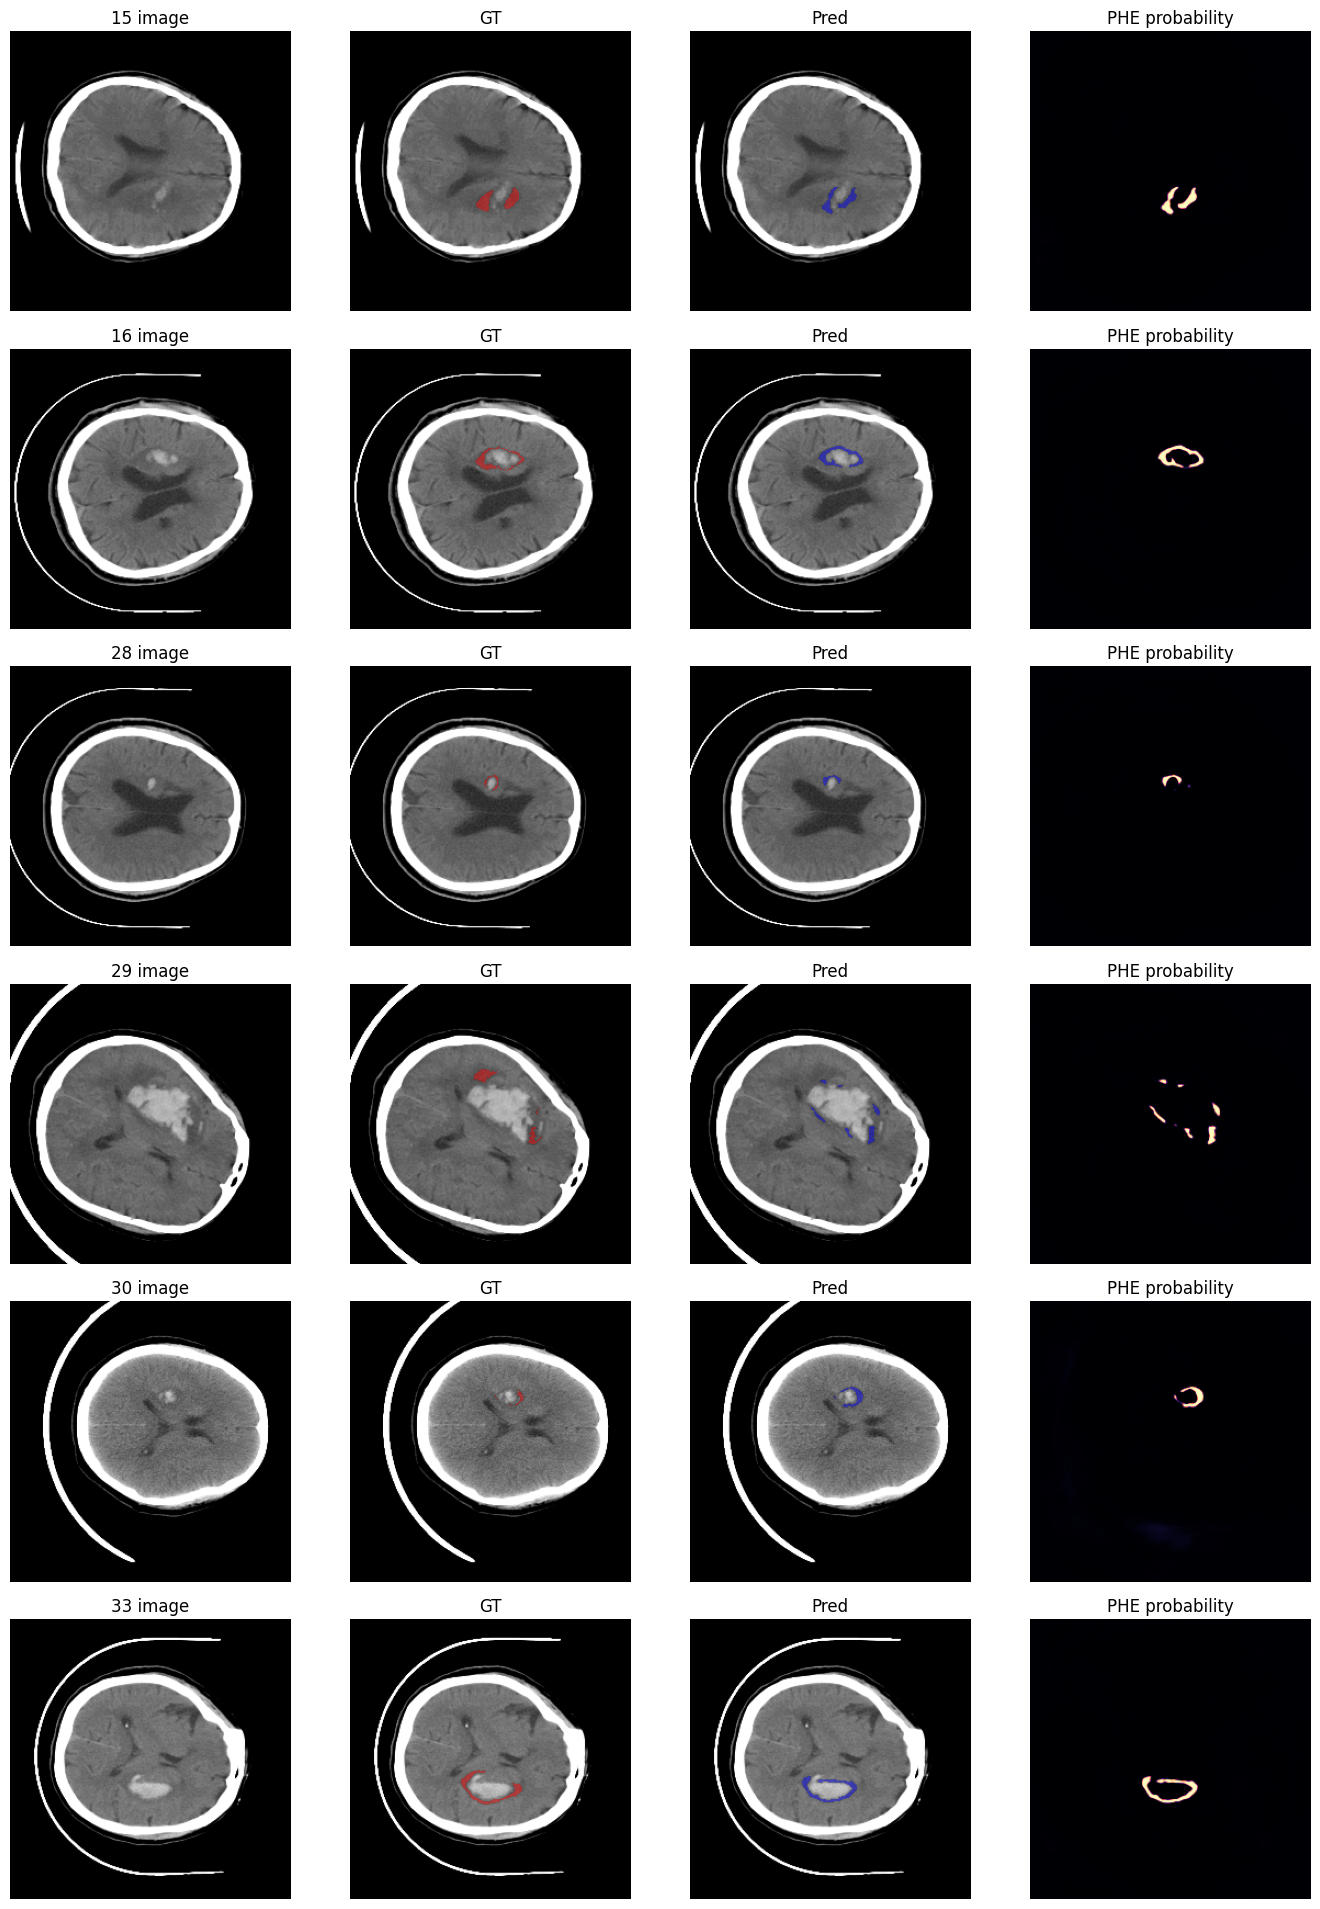

Saved protocol: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option5_ring_prior_warmstart\logs\option5_protocol.json
Tables : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option5_ring_prior_warmstart\tables
Figures: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option5_ring_prior_warmstart\figures
Ckpts  : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option5_ring_prior_warmstart\checkpoints


In [17]:
if "qualitative_cases" in globals() and qualitative_cases:
    n = len(qualitative_cases)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n))
    if n == 1:
        axes = axes[None, :]
    for r, (scan_id, img2d, gt2d, pred2d, prob2d) in enumerate(qualitative_cases):
        axes[r, 0].imshow(img2d, cmap="gray"); axes[r, 0].set_title(f"{scan_id} image")
        axes[r, 1].imshow(img2d, cmap="gray"); axes[r, 1].imshow(np.ma.masked_where(gt2d == 0, gt2d), cmap="autumn", alpha=0.45); axes[r, 1].set_title("GT")
        axes[r, 2].imshow(img2d, cmap="gray"); axes[r, 2].imshow(np.ma.masked_where(pred2d == 0, pred2d), cmap="winter", alpha=0.45); axes[r, 2].set_title("Pred")
        axes[r, 3].imshow(prob2d, cmap="magma", vmin=0, vmax=1); axes[r, 3].set_title("PHE probability")
        for c in range(4):
            axes[r, c].axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "option5_qualitative_predictions.png", dpi=160, bbox_inches="tight")
    plt.show()

protocol = {
    "option": "Option 5 - ring/distance ICH prior with Option 1 warm-start",
    "why": "Option 4 raw ICH prior caused mild negative transfer; Option 5 converts hematoma prior into ring/distance context and starts from the stronger PHE-only model.",
    "inputs": ["PHE CT brain window", "raw ICH prior", "ring prior around ICH", "distance prior from ICH"],
    "warmstart": str(OPTION1_CKPT_PATH),
    "raw_prior_source": str(OPTION4_RAW_PRIOR_DIR),
    "no_go": ["No pseudo-IPH labels inferred from PHE masks", "No RSNA/BHSD"],
    "metrics": ["Dice", "Jaccard", "full HD", "Precision", "Recall", "DSC", "HD", "RVD", "NSD", "volume MAE/RMSE/R2"],
}
with open(LOG_DIR / "option5_protocol.json", "w", encoding="utf-8") as f:
    json.dump(protocol, f, ensure_ascii=False, indent=2, default=str)
print("Saved protocol:", LOG_DIR / "option5_protocol.json")
print("Tables :", TABLE_DIR)
print("Figures:", FIG_DIR)
print("Ckpts  :", CHECKPOINT_DIR)
